# Modellierung mit Markov-Ketten

https://de.wikipedia.org/wiki/Markow-Kette

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Adaption von Robo-Taxis

Ein Robo-Taxi Dienst in einer Stadt neu ein geführt wird. Aktuell fahren alle Passagiere mit normalen Taxis.

Das Modell soll das Fahrverhalten eines Passagiers beschreiben:
- Zustand $r$: Robo Taxi
- Zustand $s$: Standard Taxi

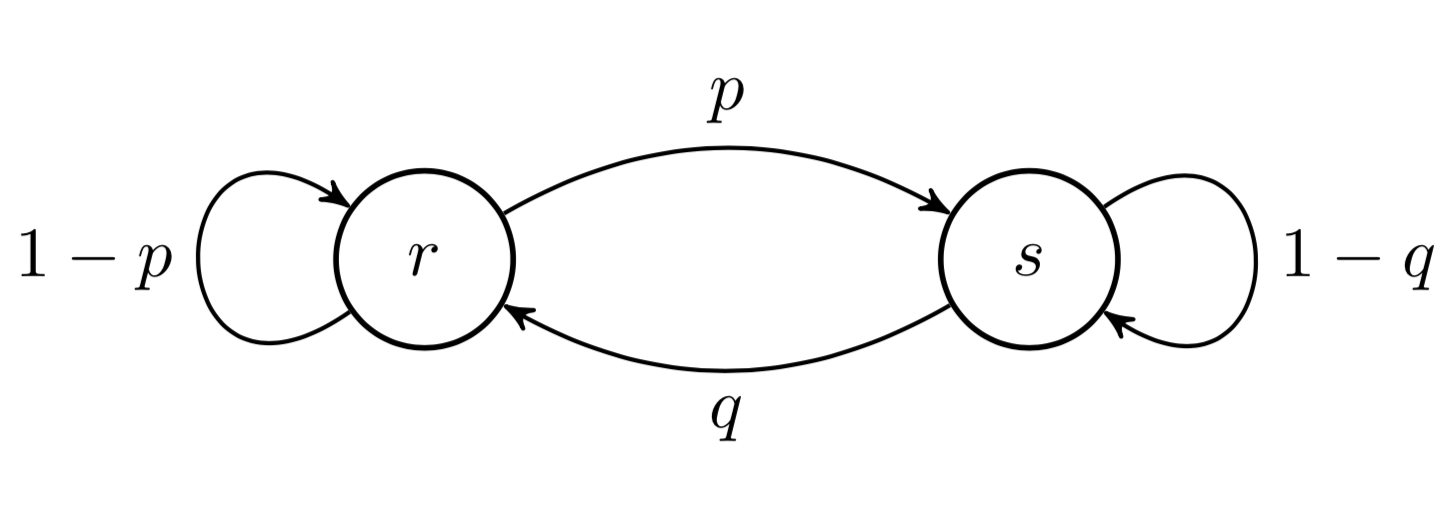

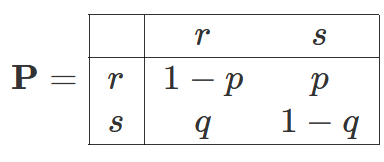

Übergangswahrscheinlichkeiten:
- Standard -> Robo: $q=0.4$ (Neugier; Preis)
- Standard -> Standard: $1-q=0.6$ (Nichts neues ausprobieren; Sicherheit)
- Robo -> Standard: $p=0.2$ (Unbehagen; schlechte Erfahrung)
- Robo -> Robo: $1-p=0.8$ (Bequemlichkeit; Preis)

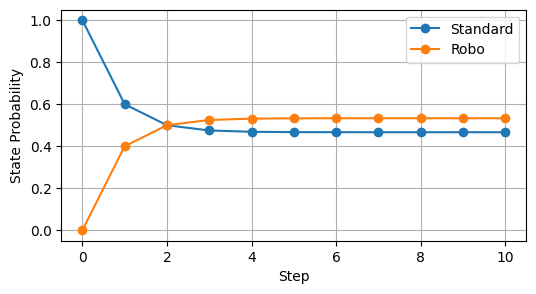

In [115]:
state_names = {0: "Standard", 1: "Robo"}
P = np.array([[0.6, 0.4], [0.35, 0.65]])

n_steps = 10
probability = [1, 0]
probabilities = [probability]
for _ in range(n_steps):
    probability = np.dot(probability, P)
    probabilities.append(probability)

plt.figure(figsize=(6, 3))
plt.plot(probabilities, marker="o")
plt.xlabel("Step")
plt.ylabel("State Probability")
plt.legend(list(state_names.values()))
plt.grid()
plt.show()

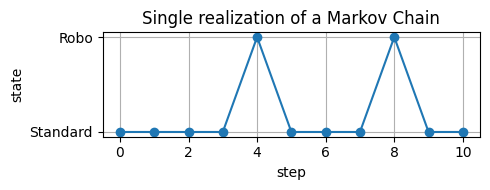

In [116]:
# Stochastic simulation of a Markov Chain


def markov_chain_simulation(P, ini_state=0, n_steps=10, seed=None):
    rng = np.random.default_rng(seed)
    state = ini_state
    chain = [state]
    for _ in range(n_steps):
        state = rng.choice([0, 1], p=P[state])
        chain.append(state)
    return np.array(chain)


chain = markov_chain_simulation(P)
chain = [state_names[s] for s in chain]

plt.figure(figsize=(5, 2))
plt.plot(chain, "o-")
plt.xlabel("step")
plt.ylabel("state")
plt.title("Single realization of a Markov Chain")
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
def markov_chain_simulation(P, ini_state=0, n_steps=10, seed=None):
    rng = np.random.default_rng(seed)
    state = ini_state
    chain = [state]
    for _ in range(n_steps):
        state = rng.choice([0, 1], p=P[state])
        chain.append(state)
    return np.array(chain)


def simulate_many_chains(P, n_chains=100, n_steps=10):
    return np.array(
        [markov_chain_simulation(P, n_steps=n_steps) for _ in range(n_chains)]
    )


P = np.array([[0.3, 0.7], [0.2, 0.8]])

chains = simulate_many_chains(P, n_chains=100)

chains_mean = chains.mean(axis=0)
chains_std = chains.std(axis=0)
chains_ci = 2.576 * chains.std(axis=0) / np.sqrt(chains.shape[0])

plt.figure(figsize=(6, 3))
(p,) = plt.plot(chains_mean, label="mean")
plt.fill_between(
    range(chains.shape[1]),
    chains_mean - chains_ci,
    chains_mean + chains_ci,
    alpha=0.2,
    label="99% CI",
)
plt.fill_between(
    range(chains.shape[1]),
    chains_mean - chains_std,
    chains_mean + chains_std,
    alpha=0.2,
    label=r"$\pm 1 \sigma$",
)
plt.xlim(0, chains.shape[1] - 1)
plt.xticks(range(chains.shape[1]), range(chains.shape[1]))
plt.ylim(0, 1)
plt.xlabel("step")
plt.ylabel(f"state (0={state_names[0]}, 1={state_names[1]})")
plt.title(f"Mean and confidence intervals of {chains.shape[0]} chains")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()